In [13]:
import os
from huggingface_hub import login
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("il-tur")
login(token=hf_token)

dataset = load_dataset("Exploration-Lab/IL-TUR", "rr")

In [ ]:
from transformers import AutoTokenizer
import numpy as np
from datasets import concatenate_datasets

model_checkpoint = "law-ai/InLegalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Combine splits for maximum training data
train_splits = [s for s in dataset.keys() if "train" in s]
eval_splits = [s for s in dataset.keys() if "dev" in s or "val" in s]

train_dataset = concatenate_datasets([dataset[s] for s in train_splits])
eval_dataset = concatenate_datasets([dataset[s] for s in eval_splits])

# Identify unique labels
all_train_labels = []
for labels_list in train_dataset['labels']:
    all_train_labels.extend(labels_list)
    
unique_labels = sorted(list(set(all_train_labels)))
num_labels = len(unique_labels)
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for i, label in enumerate(unique_labels)}

print(f"Found {num_labels} unique rhetorical roles.")

# RESEARCH IMPROVEMENT: Native Cross-Attention Segmenting
def tokenize_cross_attention(examples):
    targets = []
    contexts = []
    flat_labels = []
    
    for doc_texts, doc_labels in zip(examples['text'], examples['labels']):
        num_sentences = len(doc_texts)
        
        for i in range(num_sentences):
            current = str(doc_texts[i]).strip()
            if not current: 
                continue
                
            # Grab surrounding context
            prev_s = str(doc_texts[i-1]).strip() if i > 0 else ""
            next_s = str(doc_texts[i+1]).strip() if i < num_sentences - 1 else ""
            
            # Combine surroundings into a single "Context" block
            context = f"{prev_s} {next_s}".strip()
            
            targets.append(current)
            contexts.append(context if context else "No context.")
            flat_labels.append(label2id[doc_labels[i]])
            
    # CRITICAL: Passing two lists (targets, contexts) forces BERT to use Segment A / Segment B embeddings.
    # It will automatically format as: [CLS] Target [SEP] Context [SEP]
    result = tokenizer(targets, contexts, truncation=True, padding="max_length", max_length=256)
    result["labels"] = flat_labels
    return result

print("Tokenizing training set with Cross-Attention formatting...")
tokenized_train = train_dataset.map(
    tokenize_cross_attention, 
    batched=True, 
    remove_columns=train_dataset.column_names
)

print("Tokenizing validation set with Cross-Attention formatting...")
tokenized_eval = eval_dataset.map(
    tokenize_cross_attention, 
    batched=True, 
    remove_columns=eval_dataset.column_names
)

tokenized_train.set_format("torch")
tokenized_eval.set_format("torch")
print(f"Data ready. Training samples: {len(tokenized_train)}")

Found 13 unique rhetorical roles.
Tokenizing training set with Cross-Attention formatting...


Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Tokenizing validation set with Cross-Attention formatting...


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

✅ Data ready. Training samples: 16845


In [11]:
!pip install -q evaluate

import evaluate
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from transformers import EarlyStoppingCallback

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint, 
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# RESEARCH IMPROVEMENT: Anti-Overfitting Hyperparameters
training_args = TrainingArguments(
    output_dir="./legal_bert_checkpoints",
    learning_rate=1e-5,              # SEVERELY REDUCED: Stops the model from memorizing the training data
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=16,
    num_train_epochs=5,              
    weight_decay=0.05,               # INCREASED to 0.05: Strong L2 Regularization
    warmup_ratio=0.1,                # Allows the learning rate to scale smoothly
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,     
    metric_for_best_model="accuracy",
    fp16=True,                       
    report_to="none",
    logging_steps=50,
    dataloader_drop_last=True        
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Forgives minor dips, but stops if it diverges
)

print("Starting Anti-Overfitting Cross-Attention Training...")
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: law-ai/InLegalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect id

Starting Anti-Overfitting Cross-Attention Training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,2.723163,2.907259,0.529830
2,1.989967,2.839786,0.551136
3,1.460685,2.970495,0.557292
4,1.368775,3.074159,0.551136
5,1.129328,3.128811,0.552557


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2630, training_loss=2.0064705721779013, metrics={'train_runtime': 2195.6557, 'train_samples_per_second': 38.36, 'train_steps_per_second': 1.198, 'total_flos': 1.107280670244864e+16, 'train_loss': 2.0064705721779013, 'epoch': 5.0})

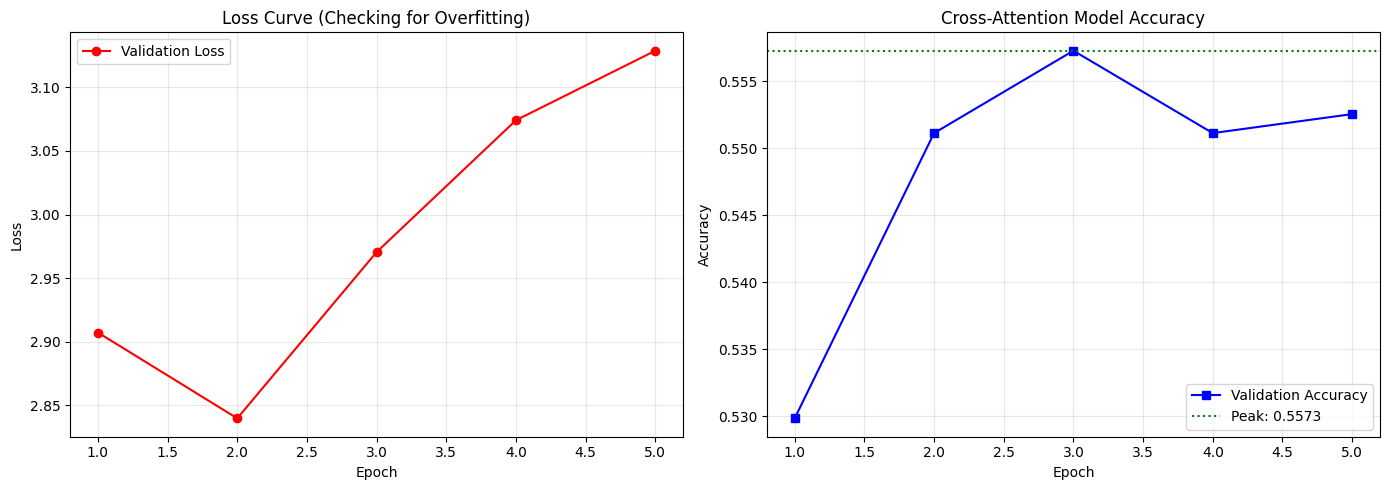

Final Peak Accuracy: 0.5573


In [12]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
eval_history = [x for x in history if 'eval_accuracy' in x]
train_history = [x for x in history if 'loss' in x and 'epoch' in x]

# Aggregate training loss per epoch for cleaner plotting
epochs = [x['epoch'] for x in eval_history]
acc = [x['eval_accuracy'] for x in eval_history]
val_loss = [x['eval_loss'] for x in eval_history]

plt.figure(figsize=(14, 5))

# Plot 1: Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
plt.title('Loss Curve (Checking for Overfitting)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, 'b-s', label='Validation Accuracy')
plt.axhline(y=max(acc), color='green', linestyle=':', label=f'Peak: {max(acc):.4f}')
plt.title('Cross-Attention Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final Peak Accuracy: {max(acc):.4f}")